# Retail & Marketing Analytics Project
## Notebook 06: Customer Churn Prediction

| | |
|---|---|
| **Project** | Retail & Marketing Analytics - Customer Segmentation & Sales Optimization |
| **Notebook** | 06 - Customer Churn Prediction |
| **Author** | Ayush Kumar Singh |
| **Date** | 16th July 2026 |

### Objectives
- Define a churn target from existing RFM data
- Build a customer-level feature table without data leakage
- Train and validate a baseline model and two classifiers (Logistic Regression, Random Forest)
- Evaluate models with metrics appropriate for imbalanced classes (ROC-AUC, precision, recall, F1)
- Identify the key drivers of churn using feature importance
- Save the trained model and generate churn-risk scores for every customer
- Translate model output into a business recommendation (revenue at risk)

### Note on Data Leakage
This notebook predicts churn using **Recency** as the label definition. Because of that,
`Recency`, `R_Score`, `RFM_Score`, `RFM_Score_Numeric`, `Customer_Segment`, `Cluster`, and
`Cluster_Name` (all derived from Recency in Notebook 04) are intentionally **excluded** from
the feature set. Only Frequency, Monetary, and independently engineered behavioral features
are used as predictors, so the model is actually learning to predict churn from behavior
rather than reading it directly off the label.


## 1. Import Libraries and Load Data
Load the cleaned transaction data (Notebook 02) and the RFM / CLV outputs (Notebook 04),
which together provide everything needed to build a churn model without recomputing
earlier steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, precision_recall_fscore_support)
import joblib

# Project paths (relative to the notebooks/ folder, matching Notebooks 01-05)
DATA_PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')
REPORTS = Path('../outputs/reports')
MODELS = Path('../outputs/models')

FIGURES.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(DATA_PROCESSED / 'cleaned_retail_sales.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

rfm = pd.read_csv(DATA_PROCESSED / 'rfm_analysis.csv')
clv = pd.read_csv(DATA_PROCESSED / 'customer_clv.csv')

print("="*80)
print("CUSTOMER CHURN PREDICTION")
print("="*80)
print(f"\nTransactions: {df.shape}")
print(f"RFM records: {rfm.shape}")
print(f"CLV records: {clv.shape}")

CUSTOMER CHURN PREDICTION

Transactions: (10000, 45)
RFM records: (1986, 10)
CLV records: (1986, 10)


## 2. Define the Churn Target
A customer is labeled **churned (1)** if their Recency (days since last purchase) exceeds
180 days, and **active (0)** otherwise. This threshold matches the churn definition already
used in Notebook 05's KPI report, keeping the two notebooks consistent.

In [2]:
CHURN_THRESHOLD_DAYS = 180

rfm['Churned'] = (rfm['Recency'] > CHURN_THRESHOLD_DAYS).astype(int)

churn_counts = rfm['Churned'].value_counts()
churn_rate = rfm['Churned'].mean() * 100

print(f"Churn threshold: > {CHURN_THRESHOLD_DAYS} days since last purchase")
print(f"\nClass balance:")
print(churn_counts)
print(f"\nOverall churn rate: {churn_rate:.2f}%")

Churn threshold: > 180 days since last purchase

Class balance:
Churned
0    1750
1     236
Name: count, dtype: int64

Overall churn rate: 11.88%


Saved: 28_churn_class_balance.png


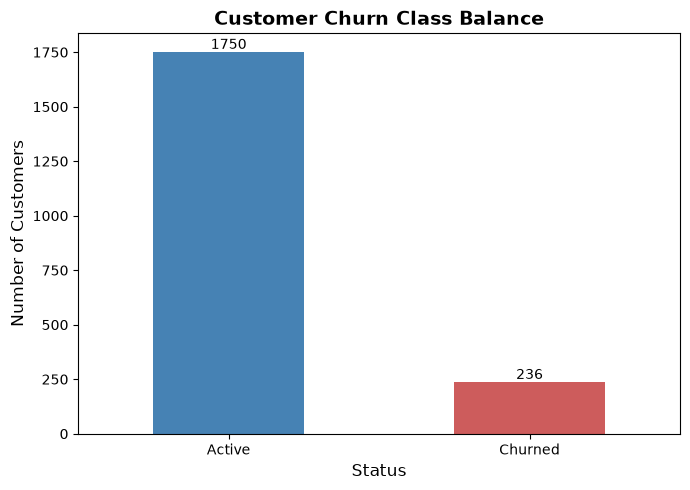


Note: the class imbalance above is why accuracy alone will be a misleading
metric for this model - a classifier that always predicts 'Active' would already
score 88.1% accuracy without learning anything useful.


In [3]:
# Visualize class balance
fig, ax = plt.subplots(figsize=(7, 5))
churn_counts.rename({0: 'Active', 1: 'Churned'}).plot(kind='bar', ax=ax,
                                                        color=['steelblue', 'indianred'])
ax.set_title('Customer Churn Class Balance', fontsize=14, fontweight='bold')
ax.set_xlabel('Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_xticklabels(['Active', 'Churned'], rotation=0)
for i, v in enumerate(churn_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.savefig(FIGURES / '28_churn_class_balance.png', dpi=300, bbox_inches='tight')
print("Saved: 28_churn_class_balance.png")
plt.show()

print("\nNote: the class imbalance above is why accuracy alone will be a misleading")
print("metric for this model - a classifier that always predicts 'Active' would already")
print(f"score {(1 - churn_rate/100)*100:.1f}% accuracy without learning anything useful.")

## 3. Build the Customer-Level Feature Table
Aggregate the transaction-level data into one row per customer, then merge in the
non-leaking RFM fields (Frequency, Monetary) and CLV fields. Categorical preferences
(favorite category, region, customer type) are taken as each customer's most frequent
value (mode).

In [4]:
agg_kwargs = {
    'Total_Sales': ('Sales', 'sum'),
    'Total_Orders': ('Order_ID', 'nunique'),
    'Avg_Order_Value': ('Sales', 'mean'),
    'Total_Quantity': ('Quantity', 'sum'),
}

if 'Discount' in df.columns:
    agg_kwargs['Avg_Discount'] = ('Discount', 'mean')
if 'Profit' in df.columns:
    agg_kwargs['Avg_Profit'] = ('Profit', 'mean')
if 'Delivery_Days' in df.columns:
    agg_kwargs['Avg_Delivery_Days'] = ('Delivery_Days', 'mean')
if 'Is_Weekend' in df.columns:
    agg_kwargs['Weekend_Order_Ratio'] = ('Is_Weekend', 'mean')
if 'Product_Category' in df.columns:
    agg_kwargs['Preferred_Category'] = ('Product_Category',
                                         lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
    agg_kwargs['Unique_Categories'] = ('Product_Category', 'nunique')
if 'Region' in df.columns:
    agg_kwargs['Preferred_Region'] = ('Region',
                                       lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
if 'Segment' in df.columns:
    agg_kwargs['Customer_Type'] = ('Segment',
                                    lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')

customer_features = df.groupby('Customer_ID').agg(**agg_kwargs).reset_index()

print(f"Customer-level feature table: {customer_features.shape[0]:,} customers, "
      f"{customer_features.shape[1]} raw columns")
print(customer_features.head())

Customer-level feature table: 1,986 customers, 13 raw columns
  Customer_ID  Total_Sales  Total_Orders  Avg_Order_Value  Total_Quantity  \
0    CUST0001   943.770842             8       117.971355              39   
1    CUST0002   617.531725             6       102.921954              29   
2    CUST0003   548.860692             5       109.772138              24   
3    CUST0004   247.117878             3        82.372626              17   
4    CUST0005   337.341185             4        84.335296              31   

   Avg_Discount  Avg_Profit  Avg_Delivery_Days  Weekend_Order_Ratio  \
0      0.112500   29.680520                1.0             0.500000   
1      0.116667   43.548708                1.0             0.333333   
2      0.050000   36.878440                1.0             0.400000   
3      0.000000   14.221973                1.0             0.333333   
4      0.062500    3.269442                1.0             0.250000   

  Preferred_Category  Unique_Categories Preferre

In [5]:
# Merge in non-leaking RFM fields and CLV fields
customer_features = customer_features.merge(
    rfm[['Customer_ID', 'Frequency', 'Monetary', 'Churned']],
    on='Customer_ID', how='left'
)

clv_cols = [c for c in ['Customer_ID', 'CLV_Simple', 'CLV_Category',
                         'Purchase_Frequency', 'Lifespan_Days'] if c in clv.columns]
customer_features = customer_features.merge(clv[clv_cols], on='Customer_ID', how='left')

print(f"Merged feature table shape: {customer_features.shape}")
print("\nMissing values per column:")
print(customer_features.isnull().sum())

Merged feature table shape: (1986, 20)

Missing values per column:
Customer_ID            0
Total_Sales            0
Total_Orders           0
Avg_Order_Value        0
Total_Quantity         0
Avg_Discount           0
Avg_Profit             1
Avg_Delivery_Days      0
Weekend_Order_Ratio    0
Preferred_Category     0
Unique_Categories      0
Preferred_Region       0
Customer_Type          0
Frequency              0
Monetary               0
Churned                0
CLV_Simple             0
CLV_Category           0
Purchase_Frequency     0
Lifespan_Days          0
dtype: int64


In [6]:
# Drop any customer without a churn label, fill remaining gaps
customer_features = customer_features.dropna(subset=['Churned'])
customer_features['Churned'] = customer_features['Churned'].astype(int)

numeric_cols_fill = customer_features.select_dtypes(include=[np.number]).columns
customer_features[numeric_cols_fill] = customer_features[numeric_cols_fill].fillna(
    customer_features[numeric_cols_fill].median()
)

categorical_features = [c for c in ['Preferred_Category', 'Preferred_Region',
                                     'Customer_Type', 'CLV_Category']
                         if c in customer_features.columns]
for c in categorical_features:
    customer_features[c] = customer_features[c].fillna('Unknown').astype(str)

print(f"Final feature table: {customer_features.shape[0]:,} customers, "
      f"{customer_features.shape[1]} columns")
print(f"Categorical features: {categorical_features}")

# Save the feature table for reference
customer_features.to_csv(DATA_PROCESSED / 'churn_features.csv', index=False)
print("\nSaved: data/processed/churn_features.csv")

Final feature table: 1,986 customers, 20 columns
Categorical features: ['Preferred_Category', 'Preferred_Region', 'Customer_Type', 'CLV_Category']

Saved: data/processed/churn_features.csv


## 4. Explore Churn by Feature
Compare how key behavioral metrics differ between active and churned customers. Clear
separation between the two groups on a feature is a good early signal that the feature
will be useful to the model.

Saved: 29_churn_feature_comparison.png


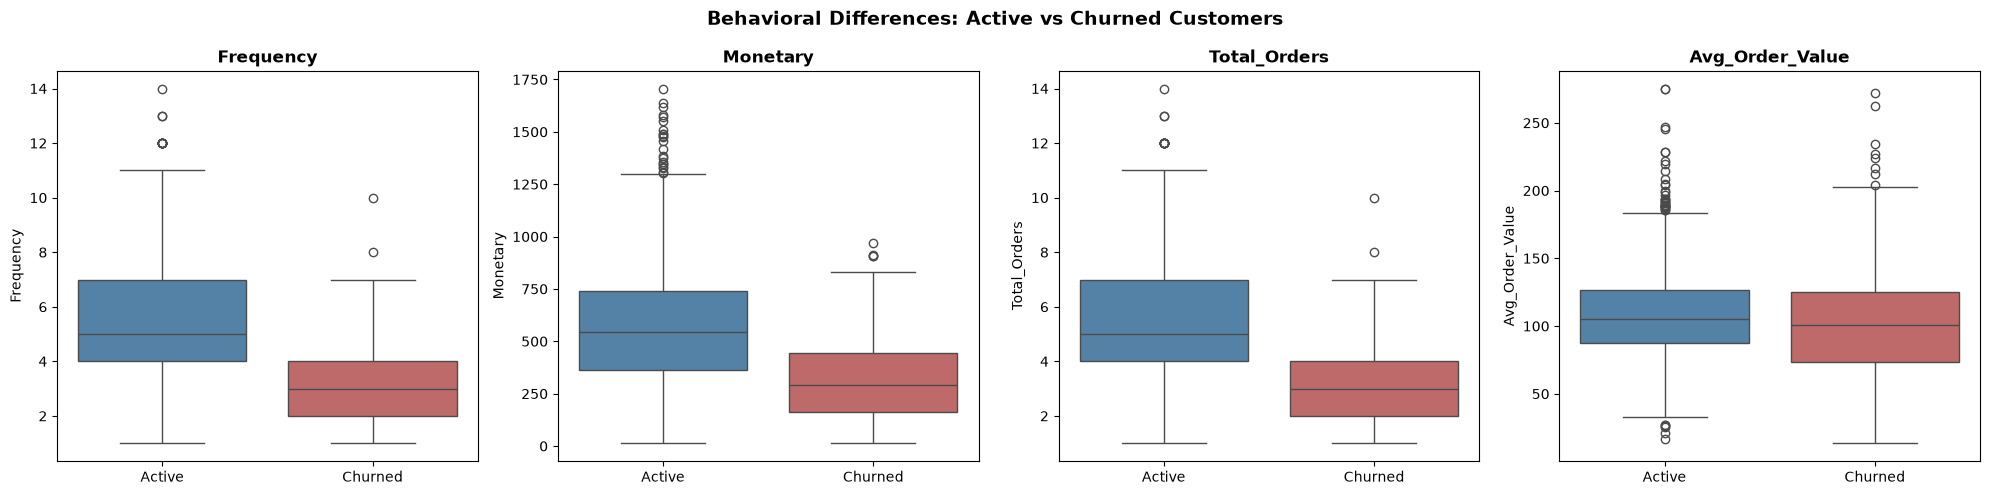

In [7]:
compare_features = [c for c in ['Frequency', 'Monetary', 'Total_Orders', 'Avg_Order_Value']
                     if c in customer_features.columns]

fig, axes = plt.subplots(1, len(compare_features), figsize=(5*len(compare_features), 5))
if len(compare_features) == 1:
    axes = [axes]

for idx, feat in enumerate(compare_features):
    sns.boxplot(data=customer_features, x='Churned', y=feat, ax=axes[idx],
                palette=['steelblue', 'indianred'])
    axes[idx].set_xticklabels(['Active', 'Churned'])
    axes[idx].set_title(feat, fontweight='bold')
    axes[idx].set_xlabel('')

plt.suptitle('Behavioral Differences: Active vs Churned Customers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '29_churn_feature_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: 29_churn_feature_comparison.png")
plt.show()

## 5. Feature Encoding and Train-Test Split
One-hot encode categorical features, split into train/test sets with stratification
(to preserve the churn ratio in both sets), and scale numeric features for the models
that are sensitive to feature magnitude.

In [8]:
X = customer_features.drop(columns=['Customer_ID', 'Churned'], errors='ignore')
y = customer_features['Churned']

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print(f"Feature matrix after encoding: {X_encoded.shape}")
print(f"Target distribution:\n{y.value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.2f}%, Test churn rate: {y_test.mean()*100:.2f}%")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled with StandardScaler")

Feature matrix after encoding: (1986, 25)
Target distribution:
Churned
0    1750
1     236
Name: count, dtype: int64

Train set: (1489, 25), Test set: (497, 25)
Train churn rate: 11.89%, Test churn rate: 11.87%

Features scaled with StandardScaler


## 6. Baseline Model
Before trusting any machine learning model, establish what a trivial baseline
(always predicting the majority class) achieves. Any real model needs to clearly beat
this baseline, especially since accuracy is misleading on imbalanced data.

In [9]:
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)
baseline_accuracy = (baseline_pred == y_test).mean()

print("BASELINE MODEL (always predicts majority class)")
print(f"Accuracy: {baseline_accuracy:.4f}")
print("This accuracy is achieved by never identifying a single churned customer,")
print("so it is not a useful model - it is only a reference point.")

BASELINE MODEL (always predicts majority class)
Accuracy: 0.8813
This accuracy is achieved by never identifying a single churned customer,
so it is not a useful model - it is only a reference point.


## 7. Logistic Regression
Train an interpretable baseline classifier with 5-fold cross-validation on the training
set (scored by ROC-AUC, which is appropriate for imbalanced classification), then evaluate
on the held-out test set. `class_weight='balanced'` compensates for the churn class being
the minority.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("LOGISTIC REGRESSION")
print(f"Cross-validated ROC-AUC: {log_cv_scores.mean():.4f} (+/- {log_cv_scores.std():.4f})")

log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)
log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

log_test_auc = roc_auc_score(y_test, log_proba)
print(f"\nTest set ROC-AUC: {log_test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, log_pred, target_names=['Active', 'Churned']))

LOGISTIC REGRESSION
Cross-validated ROC-AUC: 0.9042 (+/- 0.0135)

Test set ROC-AUC: 0.9068

Classification Report:
              precision    recall  f1-score   support

      Active       0.98      0.79      0.88       438
     Churned       0.36      0.86      0.51        59

    accuracy                           0.80       497
   macro avg       0.67      0.83      0.69       497
weighted avg       0.90      0.80      0.83       497



## 8. Random Forest
Train a non-linear ensemble model, which typically captures interactions between
behavioral features better than logistic regression, and compare its cross-validated
and test performance against the logistic regression baseline.

In [11]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("RANDOM FOREST")
print(f"Cross-validated ROC-AUC: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

rf_test_auc = roc_auc_score(y_test, rf_proba)
print(f"\nTest set ROC-AUC: {rf_test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Active', 'Churned']))

RANDOM FOREST
Cross-validated ROC-AUC: 0.9196 (+/- 0.0123)

Test set ROC-AUC: 0.9242

Classification Report:
              precision    recall  f1-score   support

      Active       0.98      0.81      0.89       438
     Churned       0.39      0.90      0.54        59

    accuracy                           0.82       497
   macro avg       0.69      0.85      0.71       497
weighted avg       0.91      0.82      0.85       497



## 9. Model Comparison: ROC Curves and Confusion Matrix
Plot both models' ROC curves on the same chart and inspect the Random Forest's
confusion matrix to see exactly how many churned customers are correctly flagged
versus missed.

Saved: 30_roc_curve_comparison.png


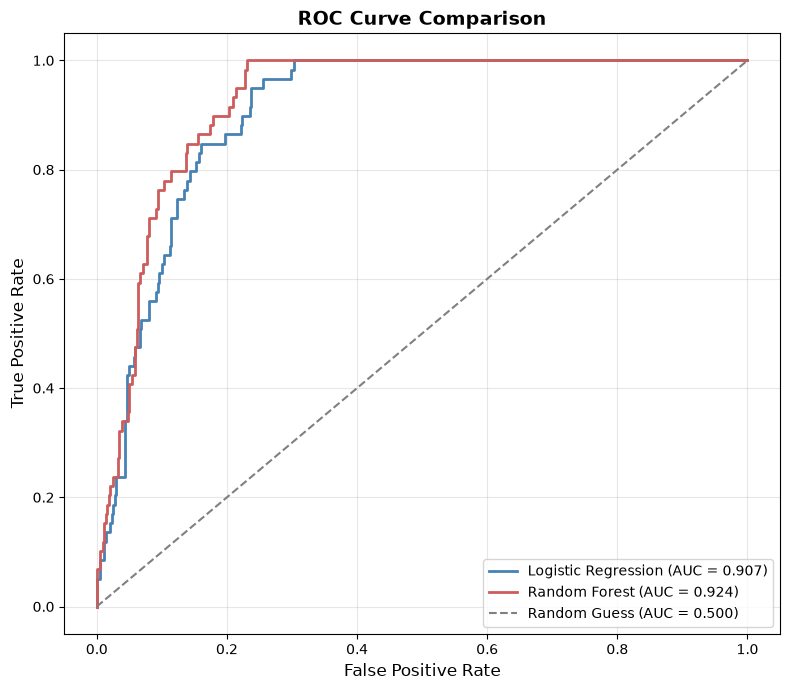

In [12]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {log_test_auc:.3f})',
        color='steelblue', linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_test_auc:.3f})',
        color='indianred', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '30_roc_curve_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: 30_roc_curve_comparison.png")
plt.show()

Saved: 31_confusion_matrix.png


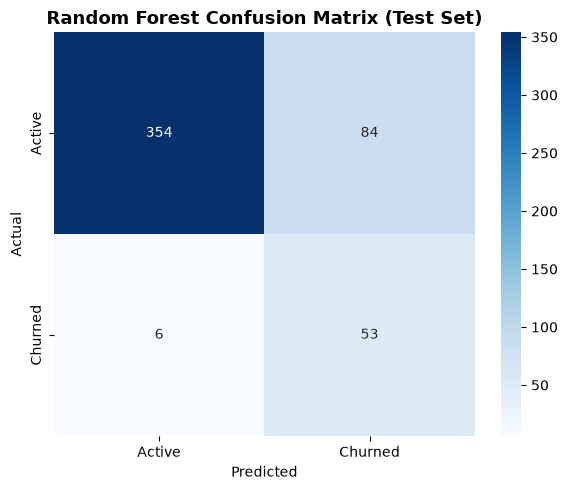


True Negatives (correctly kept as Active): 354
False Positives (Active flagged as Churned): 84
False Negatives (Churned missed by model): 6
True Positives (Churned correctly caught): 53

Of 59 actually churned customers, the model correctly identified 53 (89.8% recall).


In [13]:
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'], ax=ax)
ax.set_title('Random Forest Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES / '31_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("Saved: 31_confusion_matrix.png")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (correctly kept as Active): {tn}")
print(f"False Positives (Active flagged as Churned): {fp}")
print(f"False Negatives (Churned missed by model): {fn}")
print(f"True Positives (Churned correctly caught): {tp}")
print(f"\nOf {tp + fn} actually churned customers, the model correctly identified {tp} "
      f"({tp/(tp+fn)*100:.1f}% recall).")

## 10. Feature Importance
Identify which behavioral features drive the Random Forest's churn predictions most,
connecting the model back to the RFM story from Notebook 04.

Saved: 32_feature_importance.png


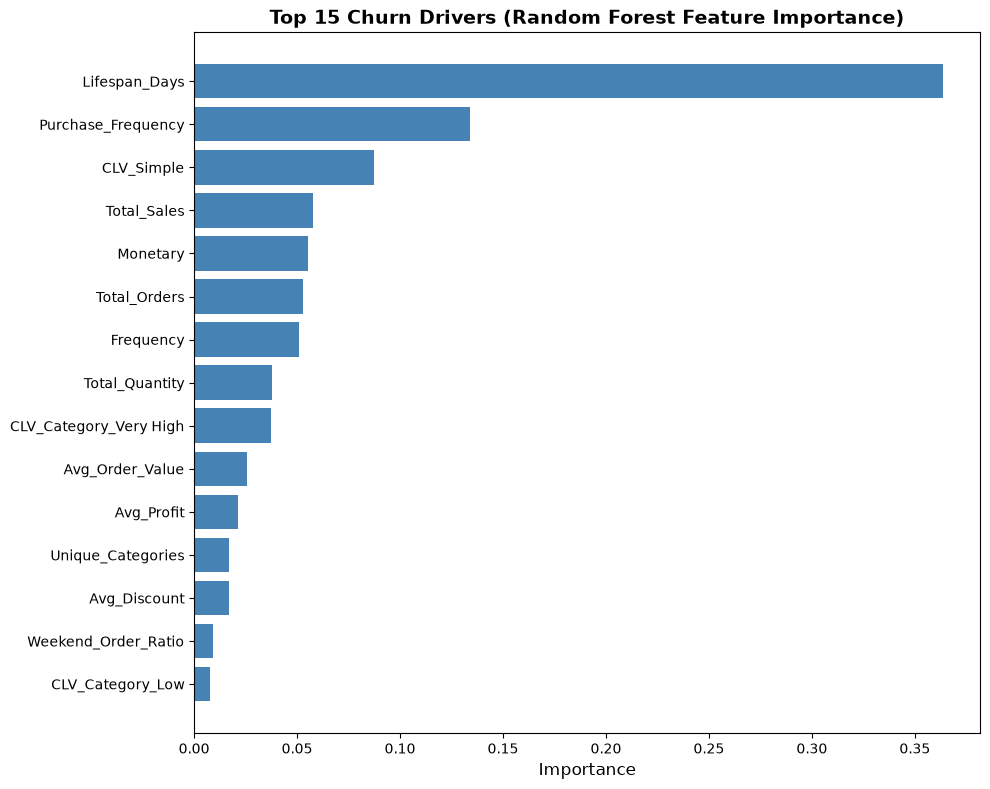


Top 10 Churn Drivers:
               Feature  Importance
         Lifespan_Days    0.363463
    Purchase_Frequency    0.133963
            CLV_Simple    0.087532
           Total_Sales    0.057582
              Monetary    0.055467
          Total_Orders    0.052817
             Frequency    0.051032
        Total_Quantity    0.037955
CLV_Category_Very High    0.037553
       Avg_Order_Value    0.025592


In [14]:
importances = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importances['Feature'][::-1], importances['Importance'][::-1], color='steelblue')
ax.set_title('Top 15 Churn Drivers (Random Forest Feature Importance)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '32_feature_importance.png', dpi=300, bbox_inches='tight')
print("Saved: 32_feature_importance.png")
plt.show()

print("\nTop 10 Churn Drivers:")
print(importances.head(10).to_string(index=False))

## 11. Save the Model and Generate Churn-Risk Scores
Persist the trained Random Forest, the fitted scaler, and the exact feature column order
so the model can be reloaded and reused without retraining. Then score every customer in
the dataset (not just the test set) with a churn probability.

In [15]:
joblib.dump(rf, MODELS / 'churn_model_rf.pkl')
joblib.dump(scaler, MODELS / 'churn_scaler.pkl')
joblib.dump(list(X_encoded.columns), MODELS / 'churn_feature_columns.pkl')

print("Saved model artifacts:")
print(f"  {MODELS / 'churn_model_rf.pkl'}")
print(f"  {MODELS / 'churn_scaler.pkl'}")
print(f"  {MODELS / 'churn_feature_columns.pkl'}")

Saved model artifacts:
  ../outputs/models/churn_model_rf.pkl
  ../outputs/models/churn_scaler.pkl
  ../outputs/models/churn_feature_columns.pkl


In [16]:
# Score every customer (not just the held-out test set)
all_proba = rf.predict_proba(scaler.transform(X_encoded))[:, 1]

churn_predictions = customer_features[['Customer_ID', 'Total_Sales']].copy()
churn_predictions['Churn_Probability'] = all_proba
churn_predictions['Predicted_Churn'] = (all_proba >= 0.5).astype(int)
churn_predictions['Actual_Churn'] = y.values

if 'CLV_Simple' in customer_features.columns:
    churn_predictions['CLV_Simple'] = customer_features['CLV_Simple'].values

churn_predictions = churn_predictions.sort_values('Churn_Probability', ascending=False)
churn_predictions.to_csv(DATA_PROCESSED / 'churn_predictions.csv', index=False)

print(f"Scored {len(churn_predictions):,} customers")
print("Saved: data/processed/churn_predictions.csv")
print("\nHighest risk customers:")
print(churn_predictions.head(10).to_string(index=False))

Scored 1,986 customers
Saved: data/processed/churn_predictions.csv

Highest risk customers:
Customer_ID  Total_Sales  Churn_Probability  Predicted_Churn  Actual_Churn    CLV_Simple
   CUST1898    96.862389           0.950528                1             1 106136.962971
   CUST0409    29.578477           0.949575                1             1  32410.616320
   CUST1569    98.437074           0.947765                1             1 107862.424108
   CUST1729   126.737120           0.947015                1             1 138872.199688
   CUST1198   101.148101           0.946940                1             1 110833.031683
   CUST1484    77.040777           0.945053                1             1  84417.431176
   CUST0174   126.500606           0.944570                1             1 138613.039363
   CUST0677    35.824777           0.940039                1             1  39254.999415
   CUST0186   124.691818           0.937351                1             1 136631.059701
   CUST0158   137.

## 12. Business Translation: Revenue at Risk
Translate the model's output into a business number: identify the top 20% highest-risk
customers by predicted churn probability, and estimate how much historical revenue they
represent using actual historical sales (more defensible than the CLV formula, which can
be distorted by short-lifespan outliers). This is the number a stakeholder actually cares
about.

In [17]:
risk_threshold = churn_predictions['Churn_Probability'].quantile(0.80)
high_risk = churn_predictions[churn_predictions['Churn_Probability'] >= risk_threshold]

revenue_at_risk = high_risk['Total_Sales'].sum()
total_revenue = churn_predictions['Total_Sales'].sum()
revenue_at_risk_pct = (revenue_at_risk / total_revenue) * 100

print("="*80)
print("REVENUE AT RISK ANALYSIS")
print("="*80)
print(f"\nHigh-risk threshold (80th percentile churn probability): {risk_threshold:.3f}")
print(f"High-risk customers: {len(high_risk):,} ({len(high_risk)/len(churn_predictions)*100:.1f}% of base)")
print(f"Historical revenue represented by high-risk customers: ${revenue_at_risk:,.2f}")
print(f"Share of total historical revenue: {revenue_at_risk_pct:.2f}%")

model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(
    y_test, rf_pred, average='binary'
)

business_report = f"""
CHURN PREDICTION MODEL - BUSINESS SUMMARY
{'='*80}

MODEL PERFORMANCE (Random Forest, Test Set):
  - ROC-AUC: {rf_test_auc:.3f}
  - Precision (Churned class): {model_precision:.3f}
  - Recall (Churned class): {model_recall:.3f}
  - F1 Score (Churned class): {model_f1:.3f}
  - Baseline accuracy (majority class): {baseline_accuracy:.3f}

CHURN OVERVIEW:
  - Overall churn rate: {churn_rate:.2f}%
  - Churn definition: no purchase in the last {CHURN_THRESHOLD_DAYS} days

REVENUE AT RISK:
  - High-risk customers (top 20% by predicted probability): {len(high_risk):,}
  - Historical revenue represented: ${revenue_at_risk:,.2f} ({revenue_at_risk_pct:.2f}% of total)

TOP CHURN DRIVERS:
{chr(10).join(f"  - {row.Feature}: {row.Importance:.3f}" for row in importances.head(5).itertuples())}

RECOMMENDATION:
  Prioritize retention outreach (win-back offers, personalized re-engagement) toward the
  {len(high_risk):,} customers flagged as high-risk, rather than treating all customers
  uniformly. Given the model recall of {model_recall:.1%}, expect that some churned
  customers will still be missed - this model should support, not replace, the existing
  RFM-based segmentation from Notebook 04.

Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

with open(REPORTS / 'churn_model_report.txt', 'w') as f:
    f.write(business_report)

print(business_report)
print("Saved: outputs/reports/churn_model_report.txt")

print("\n" + "="*80)
print("NOTEBOOK 06 COMPLETED SUCCESSFULLY!")
print("="*80)

REVENUE AT RISK ANALYSIS

High-risk threshold (80th percentile churn probability): 0.639
High-risk customers: 398 (20.0% of base)
Historical revenue represented by high-risk customers: $124,221.86
Share of total historical revenue: 11.52%

CHURN PREDICTION MODEL - BUSINESS SUMMARY

MODEL PERFORMANCE (Random Forest, Test Set):
  - ROC-AUC: 0.924
  - Precision (Churned class): 0.387
  - Recall (Churned class): 0.898
  - F1 Score (Churned class): 0.541
  - Baseline accuracy (majority class): 0.881

CHURN OVERVIEW:
  - Overall churn rate: 11.88%
  - Churn definition: no purchase in the last 180 days

REVENUE AT RISK:
  - High-risk customers (top 20% by predicted probability): 398
  - Historical revenue represented: $124,221.86 (11.52% of total)

TOP CHURN DRIVERS:
  - Lifespan_Days: 0.363
  - Purchase_Frequency: 0.134
  - CLV_Simple: 0.088
  - Total_Sales: 0.058
  - Monetary: 0.055

RECOMMENDATION:
  Prioritize retention outreach (win-back offers, personalized re-engagement) toward the
  3

---
### Summary

In this notebook we:
- Defined a churn label from Recency (>180 days since last purchase) while explicitly
  excluding all Recency-derived fields from the feature set to avoid data leakage
- Built a customer-level feature table combining transaction aggregates, RFM Frequency/Monetary,
  and CLV metrics
- Established a baseline (majority-class) model to make clear why accuracy alone is
  misleading on this imbalanced target
- Trained and cross-validated Logistic Regression and Random Forest classifiers, evaluated
  with ROC-AUC, precision, recall, and F1
- Compared both models with ROC curves and inspected the Random Forest's confusion matrix
- Identified the top churn drivers via feature importance
- Saved the trained model, scaler, and feature schema as reusable artifacts, and scored
  every customer with a churn probability
- Translated the model into a business number: revenue at risk from the top 20% highest-risk
  customers, plus a written recommendation

This extends the project from descriptive customer analytics (Notebooks 01-05) into
predictive analytics, while staying consistent with the RFM segmentation already built
in Notebook 04.
